# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Experiment 6

Summary: change the prediction length from 10 days in the future to 30 days into the future.

Important differences:
- Use dates and charts as in experiment 5
- Change the delay (prediction length) in order to predict the value 30 days into the future
- Change the sequence length from 10 days to 60 days (past observations)

## Preparing the data

### Transforming the csv data to a numpy array

In [1]:
import numpy as np

str_to_np_date = lambda x: np.datetime64(x)

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=1)
usdYen_raw_data_dates = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=0, converters={0: str_to_np_date})

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)
print("Raw Data Dates: ",usdYen_raw_data_dates)

Length:  5000
Data type:  float64
Raw Data:  [154.71 155.21 155.81 ... 118.22 118.89 118.46]
Raw Data Dates:  ['2025-12-16' '2025-12-15' '2025-12-12' ... '2006-10-19' '2006-10-18'
 '2006-10-17']


As the currency data is from newer to older, the order should be inverted.

In [2]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[118.46 118.89 118.22 ... 155.81 155.21 154.71]


### Computing the numer of samples for each data split

In [3]:
train_samples_number = len(usdYen_raw_data)
print("Number of train samples: ", train_samples_number)

Number of train samples:  5000


### Creating timeseries data

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [4]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 60 # Observations will go back 60 days
delay = sampling_rate * (sequence_length + 30 - 1) # target is 30 days weeks after the end of the sequence
batch_size = train_samples_number

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

### - Checking that timeseries data works correctly

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [5]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[118.46, 118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21, 117.74, 118.02, 117.92, 116.72, 116.28, 115.83, 116.09, 116.16, 116.39, 115.8, 115.43, 115.28, 114.88, 115.25, 115.25, 116.32, 116.97, 116.76, 117.56, 117.83, 118.16, 118.13, 118.1, 118.43, 118.33, 118.84, 118.73, 119.14, 118.77, 118.91, 119.05, 119.02, 118.83, 119.36, 119.04, 118.62, 118.8] 119.54
[118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21, 117.74, 118.02, 117.92, 116.72, 116.28, 115.83, 116.09, 116.16, 116.39, 115.8, 115.43, 115.28, 114.88, 115.25, 115.25, 116.32, 116.97, 116.76, 117.56, 117.83, 118.16, 118.13, 118.1, 118.43, 118.33, 118.84, 118.73, 119.14, 118.77, 118.91, 119.05, 119.02, 118.83, 119.36, 119.04, 118.62, 118.8, 119.38] 120.01
[118.22, 118.7, 119.34, 119.42, 119.01, 

2026-01-11 18:32:56.078994: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### - Extracting data inputs and outputs

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [6]:
import tensorflow as tf

data_inputs = []
data_outputs = []

for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
    data_outputs = tf.reshape(tf.make_ndarray(tf.make_tensor_proto(targets)), [-1,1])

data_inputs_test = data_inputs[-200:]
data_outputs_test = data_outputs[-200:]
data_inputs = data_inputs[:-200]
data_outputs = data_outputs[:-200]

print("Data Inputs: ", len(data_inputs))
print("Data Inputs Test: ", len(data_inputs_test))
print("Data Outputs: ", len(data_outputs))
print("Data Outputs Test: ", len(data_outputs_test))
    

Samples:  tf.Tensor(
[[118.46  118.89  118.22  ... 119.04  118.62  118.8  ]
 [118.89  118.22  118.7   ... 118.62  118.8   119.38 ]
 [118.22  118.7   119.34  ... 118.8   119.38  119.67 ]
 ...
 [144.474 143.648 144.029 ... 147.1   147.72  148.14 ]
 [143.648 144.029 142.55  ... 147.72  148.14  147.83 ]
 [144.029 142.55  142.74  ... 148.14  147.83  147.38 ]], shape=(4852, 60), dtype=float64)
Sample shape:  (4852, 60)
Targets:  tf.Tensor([119.54 120.01 120.88 ... 147.71 147.62 148.9 ], shape=(4852,), dtype=float64)
Targets shape:  (4852,)
Data Inputs:  4652
Data Inputs Test:  200
Data Outputs:  4652
Data Outputs Test:  200


2026-01-11 18:32:56.253908: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
print("----")
print("Input Data: ", data_inputs)
print("----")
print("Output Data: ", data_outputs)
print("----")

----
Input Data:  [[118.46  118.89  118.22  ... 119.04  118.62  118.8  ]
 [118.89  118.22  118.7   ... 118.62  118.8   119.38 ]
 [118.22  118.7   119.34  ... 118.8   119.38  119.67 ]
 ...
 [146.833 147.123 149.293 ... 152.04  152.946 152.119]
 [147.123 149.293 147.579 ... 152.946 152.119 151.609]
 [149.293 147.579 146.561 ... 152.119 151.609 154.616]]
----
Output Data:  tf.Tensor(
[[119.54 ]
 [120.01 ]
 [120.88 ]
 ...
 [154.115]
 [153.412]
 [154.815]], shape=(4652, 1), dtype=float64)
----


## Simple LSTM Model

In [8]:
from keras import models
from keras import layers

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(16, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(8))
    model.add(layers.Dense(1))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    model.summary()
    return model

prototype_model = build_lstm_model()

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

## Genetic Algorithm

The code for the Genetic Algorithm is based on the code provided by the PyGAD library documentation [2].

### - Instance of the pygad.kerasga.KerasGA class

In [9]:
import pygad.kerasga

keras_ga = pygad.kerasga.KerasGA(model=prototype_model, num_solutions=40)

### - Fitness function

In [10]:
def fitness_function(ga_instance, solution, solution_index):
    global data_inputs, data_outputs, keras_ga, prototype_model
    predictions = pygad.kerasga.predict(model=prototype_model, solution=solution, data=data_inputs)
    mae = keras.losses.MeanAbsoluteError()
    absolute_error = mae(data_outputs, predictions).numpy() + 0.00000001
    solution_fitness = 20 / absolute_error
    return solution_fitness

### - Track GA

In [11]:
def on_generation(ga_instance):
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution()[1]}")

### - Create instance of the pygad.GA class

In [12]:
num_generations = 500
num_parents_mating = 10
initial_population = keras_ga.population_weights

ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       initial_population=initial_population,
                       fitness_func=fitness_function,
                       on_generation=on_generation,
                       suppress_warnings=True,
                       parallel_processing=["thread", 8]
                       )

In [13]:
ga_instance.run()

Generation = 1
Fitness    = 0.19646334648132324
Generation = 2
Fitness    = 0.1987844705581665
Generation = 3
Fitness    = 0.19901153445243835
Generation = 4
Fitness    = 0.2091003805398941
Generation = 5
Fitness    = 0.21466107666492462
Generation = 6
Fitness    = 0.2218325138092041
Generation = 7
Fitness    = 0.23064973950386047
Generation = 8
Fitness    = 0.23529113829135895
Generation = 9
Fitness    = 0.23529113829135895
Generation = 10
Fitness    = 0.2542092800140381
Generation = 11
Fitness    = 0.2661193013191223
Generation = 12
Fitness    = 0.26749125123023987
Generation = 13
Fitness    = 0.33540913462638855
Generation = 14
Fitness    = 0.3621966242790222
Generation = 15
Fitness    = 0.40440458059310913
Generation = 16
Fitness    = 0.45232081413269043
Generation = 17
Fitness    = 0.45232081413269043
Generation = 18
Fitness    = 0.5235862731933594
Generation = 19
Fitness    = 0.6273722052574158
Generation = 20
Fitness    = 0.6646528840065002
Generation = 21
Fitness    = 0.6646528

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


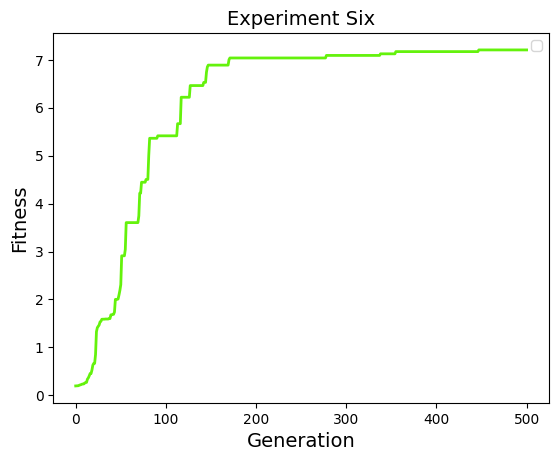

Figure(640x480)


In [14]:
print(ga_instance.plot_fitness(title="Experiment Six", linewidth=2))

### - Run best solution

In [15]:
solution, solution_fitness, solution_index = ga_instance.best_solution()
predictions = pygad.kerasga.predict(model=prototype_model, solution=solution,data=data_inputs)
mae = keras.losses.MeanAbsoluteError()
absolute_error = mae(data_outputs, predictions).numpy()
print("Solution fitness: ", solution_fitness, " (20 is the best)")
print("Predictions: ", predictions)
print("Absolute Error: ", absolute_error)

Solution fitness:  7.2076936  (20 is the best)
Predictions:  [[119.6469 ]
 [120.28034]
 [120.44503]
 ...
 [152.2424 ]
 [152.02293]
 [154.56181]]
Absolute Error:  2.7748127


### - Save Genetic Algorithm and export ML model

**Save Genetic Algorithm**

In [16]:
ga_instance.save(filename="genetic-algorithms/genetic_algorithm_experiment_six")

**Export model (keras and tensorflow)**

In [17]:
# Get the best solution as a keras weight matrix
ga_best_solution_weights = pygad.kerasga.model_weights_as_matrix(model=prototype_model, weights_vector=solution)

# Set the weights
prototype_model.set_weights(ga_best_solution_weights)

In [18]:
# Save the model (for Keras)
prototype_model.save("models/experiment_six_prototype_model.keras")

# Save the model (for Tensorflow)
prototype_model.export("models/experiment_six_prototype_model_tf", format="tf_saved_model")

INFO:tensorflow:Assets written to: models/experiment_six_prototype_model_tf/assets


INFO:tensorflow:Assets written to: models/experiment_six_prototype_model_tf/assets


Saved artifact at 'models/experiment_six_prototype_model_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5056143120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5056144080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5056141968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5056141776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5056146000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5056142928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5056146576: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Prediction using loaded model

### - Load model and make a prediction

Load the model

In [19]:
from keras.models import load_model

loaded_model = load_model("models/experiment_six_prototype_model.keras")

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 9 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Make a prediction

In [20]:
keras_predictions_loaded_model = loaded_model.predict(data_inputs)
mae_loaded_model = keras.losses.MeanAbsoluteError()
absolute_error_loaded_model = mae(data_outputs, keras_predictions_loaded_model).numpy()
print("Predictions (loaded_model): ", keras_predictions_loaded_model)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model)

146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions (loaded_model):  [[119.6469 ]
 [120.28034]
 [120.44503]
 ...
 [152.2424 ]
 [152.02293]
 [154.56181]]
Absolute Error (loaded_model):  2.7748127


Same Absolute Error as the best solution of the Genetic Algorithm. This means that the model was saved correctly.

### - Test loaded model using test data

Using test_data check the MAE of the model. This data has not been used before, and thus works as a good way of measuring the performance of the model.

In [21]:
keras_predictions_loaded_model_with_test_data = loaded_model.predict(data_inputs_test)
absolute_error_loaded_model_with_test_data = mae(data_outputs_test, keras_predictions_loaded_model_with_test_data).numpy()
print("Predictions (loaded_model with test data): ", keras_predictions_loaded_model_with_test_data)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model_with_test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions (loaded_model with test data):  [[152.69128]
 [152.85478]
 [153.75667]
 [154.3415 ]
 [154.93001]
 [155.47845]
 [153.89429]
 [154.5439 ]
 [154.4453 ]
 [155.12218]
 [154.32721]
 [154.69571]
 [154.20905]
 [153.40936]
 [151.8489 ]
 [152.65225]
 [150.86914]
 [151.1592 ]
 [151.12903]
 [152.03825]
 [151.42137]
 [151.5201 ]
 [152.63654]
 [153.05354]
 [153.42268]
 [153.53838]
 [154.47388]
 [154.67499]
 [154.06802]
 [155.40813]
 [157.23041]
 [156.14319]
 [156.9548 ]
 [156.8816 ]
 [156.97746]
 [157.56505]
 [157.37029]
 [156.72966]
 [157.17384]
 [157.14935]
 [157.34384]
 [157.20218]
 [157.4788 ]
 [157.81413]
 [158.02855]
 [157.85045]
 [157.56789]
 [157.49814]
 [157.91522]
 [156.65054]
 [155.82776]
 [156.9742 ]
 [156.15349]
 [156.00546]
 [157.15111]
 [156.5428 ]
 [156.59764]
 [155.39885]
 [156.5119 ]
 [156.01945]
 [155.35655]
 [156.27458]
 [155.6591 ]
 [155.47343]
 [153.97163]
 [153.14499]
 [153.37334]
 [153.87425]
 [154.18524]
 [155.80649]
 [154.009

Visualize predicted values

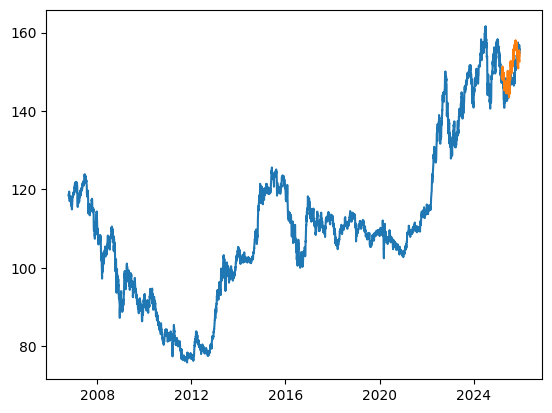

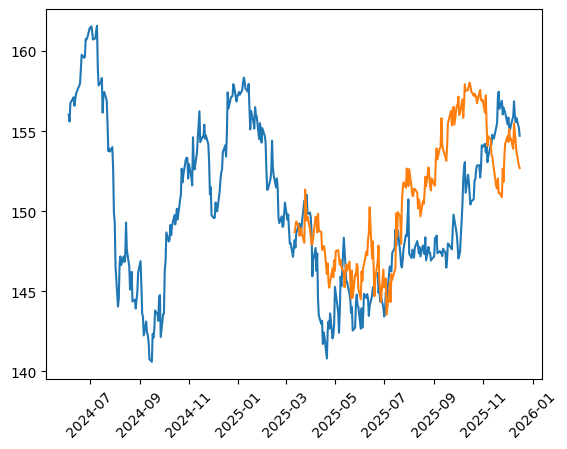

In [22]:
import matplotlib.pyplot as plt

# Flip data as it flips back again for some reason
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)

# Full data
plt.plot(usdYen_raw_data_dates, usdYen_raw_data)
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
plt.show()

# Zoom in on data
fig, ax = plt.subplots()
plt.plot(usdYen_raw_data_dates[:400], usdYen_raw_data[:400])
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
ax.tick_params("x", rotation=45)
plt.show()

## About the code

The Genetic Algorithm code is based on the code shown in the docs of the PyGAD library.

The timeseries data code is based on the code shown in the chapter of the book Deep Learning with Python.

## References

1- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries. Manning Publications.

2- PyGAD. pygad.kerasga Module. Retrieved from https://pygad.readthedocs.io/en/latest/kerasga.html#